In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Laptops.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Brand      72 non-null     object 
 1   Processor  72 non-null     object 
 2   RAM        72 non-null     object 
 3   SSD        66 non-null     object 
 4   Display    72 non-null     object 
 5   Price      72 non-null     object 
 6   Rating     63 non-null     float64
 7   Discount   72 non-null     object 
dtypes: float64(1), object(7)
memory usage: 4.6+ KB


In [4]:
df.head()

,Brand,Processor,RAM,SSD,Display,Price,Rating,Discount
0,MOTOROLA Motobook 60 Pro Full Metal AI PC 2.8K...,Intel Core Ultra 5 Processor,16 GB DDR5 RAM,512 GB SSD,35.56 cm (14 inch) Display,"₹78,990",4.4,24% off
1,Samsung Galaxy Book4 Metal Intel Core i5 13th ...,Intel Core i5 Processor (13th Gen),8 GB LPDDR4X RAM,512 GB SSD,39.62 cm (15.6 Inch) Display,"₹55,311",4.4,29% off
2,Lenovo Chromebook 11IJL9 Intel Celeron Dual Co...,Intel Celeron Dual Core Processor,4 GB LPDDR4X RAM,NaN,29.46 cm (11.6 Inch) Display,"₹13,990",4.0,55% off
3,ASUS Vivobook 15 (2025) with Office 2024 + M36...,Intel Core i3 Processor (13th Gen),8 GB DDR5 RAM,512 GB SSD,39.62 cm (15.6 Inch) Display,"₹42,990",4.3,15% off
4,ASUS TUF Gaming A15 (2026) AMD Ryzen 7 170 - (...,AMD Ryzen 7 Processor,16 GB DDR5 RAM,512 GB SSD,39.62 cm (15.6 inch) Display,"₹70,990",4.6,16% off


In [5]:
# Checking null values
df.isnull().any()

Brand        False
Processor    False
RAM          False
SSD           True
Display      False
Price        False
Rating        True
Discount     False
dtype: bool

In [6]:
# Checking no.of null values
df.isnull().sum()

Brand        0
Processor    0
RAM          0
SSD          6
Display      0
Price        0
Rating       9
Discount     0
dtype: int64

In [7]:
# Checking the percentage of null values
round(df.isnull().sum()/len(df)*100,2)

Brand         0.00
Processor     0.00
RAM           0.00
SSD           8.33
Display       0.00
Price         0.00
Rating       12.50
Discount      0.00
dtype: float64

In [8]:
## Count and percentage
pd.DataFrame({"Count":df.isnull().sum(),
             "Percentage":round(df.isnull().sum()/len(df)*100,2)})

,Count,Percentage
Brand,0,0.00
Processor,0,0.00
RAM,0,0.00
SSD,6,8.33
Display,0,0.00
Price,0,0.00
Rating,9,12.50
Discount,0,0.00


In [9]:
## Only numeric data columns
dfn = df.select_dtypes(include = ['int','float'])
pd.DataFrame({"Count":dfn.isnull().sum(),
             "Percentage":round(dfn.isnull().sum()/len(dfn)*100,2)})

,Count,Percentage
Rating,9,12.5


In [10]:
## Categorical data columns
dfc = df.select_dtypes(exclude = ['float','int'])
pd.DataFrame({"Count":dfc.isnull().sum(),
             "Percentage":round(dfc.isnull().sum()/len(dfc)*100,2)})

,Count,Percentage
Brand,0,0.00
Processor,0,0.00
RAM,0,0.00
SSD,6,8.33
Display,0,0.00
Price,0,0.00
Discount,0,0.00


In [11]:
import missingno as msno

<Axes: >

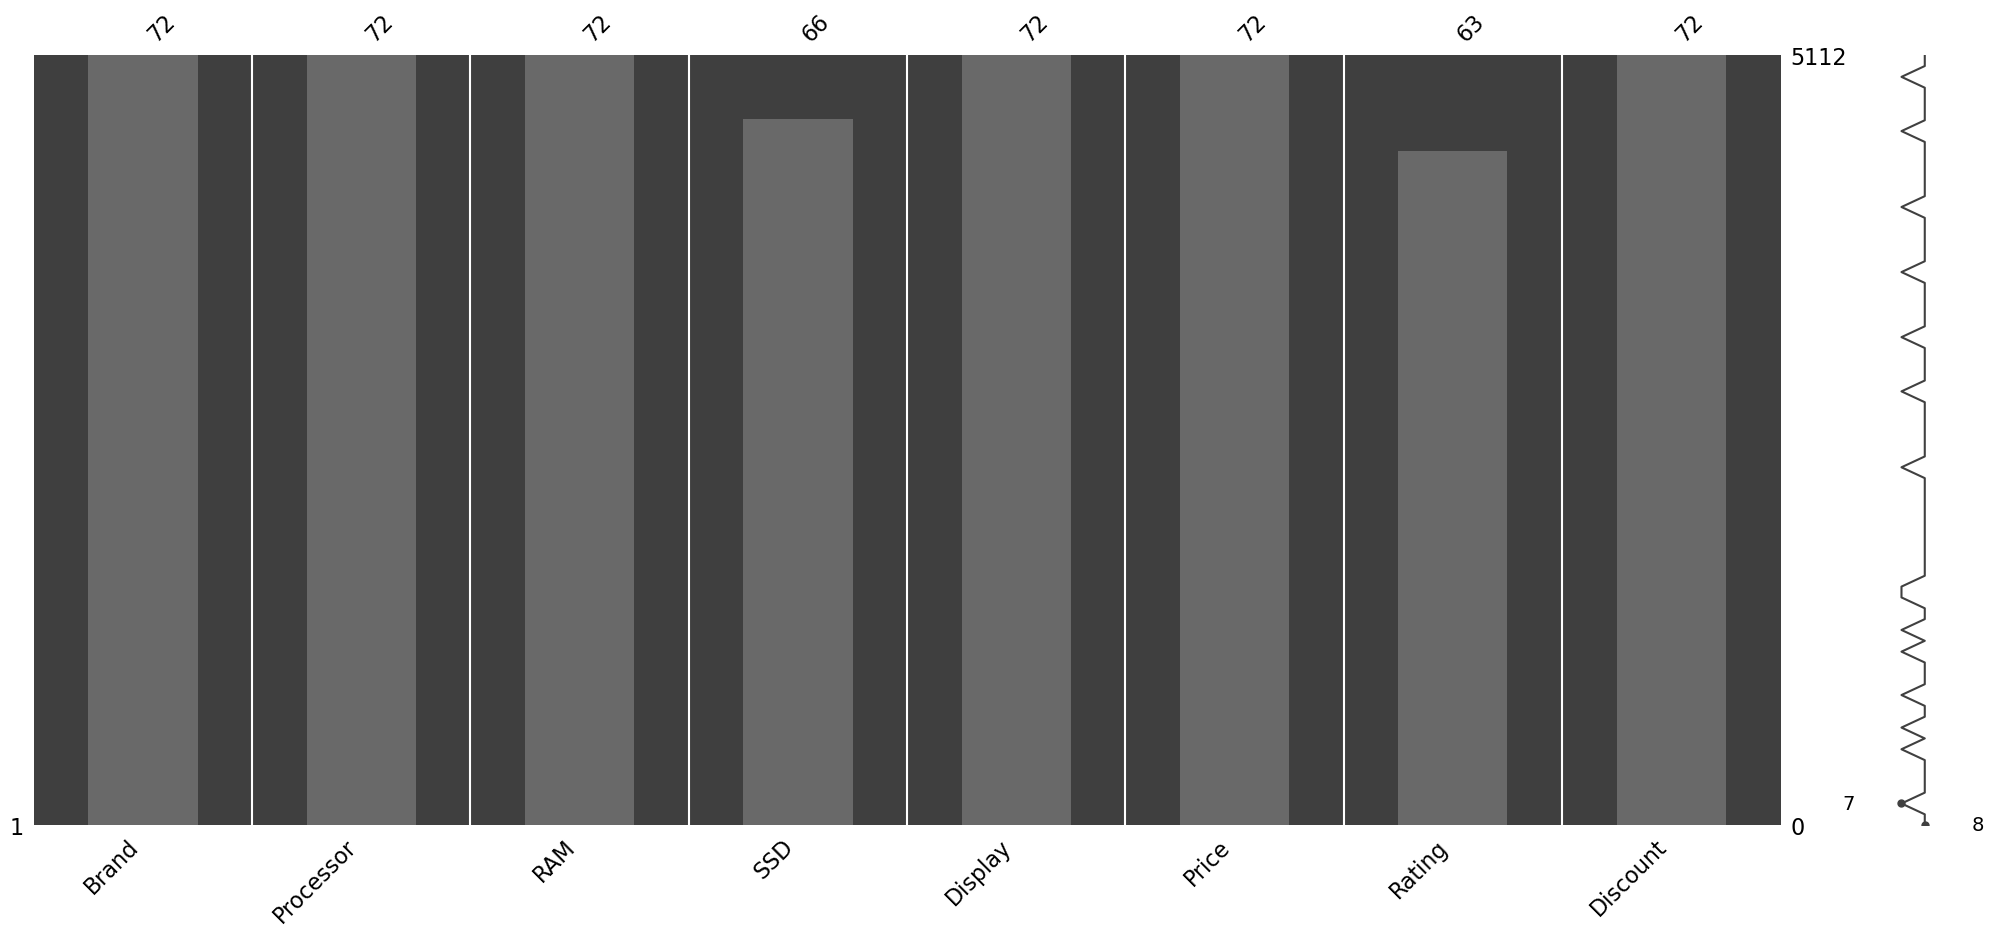

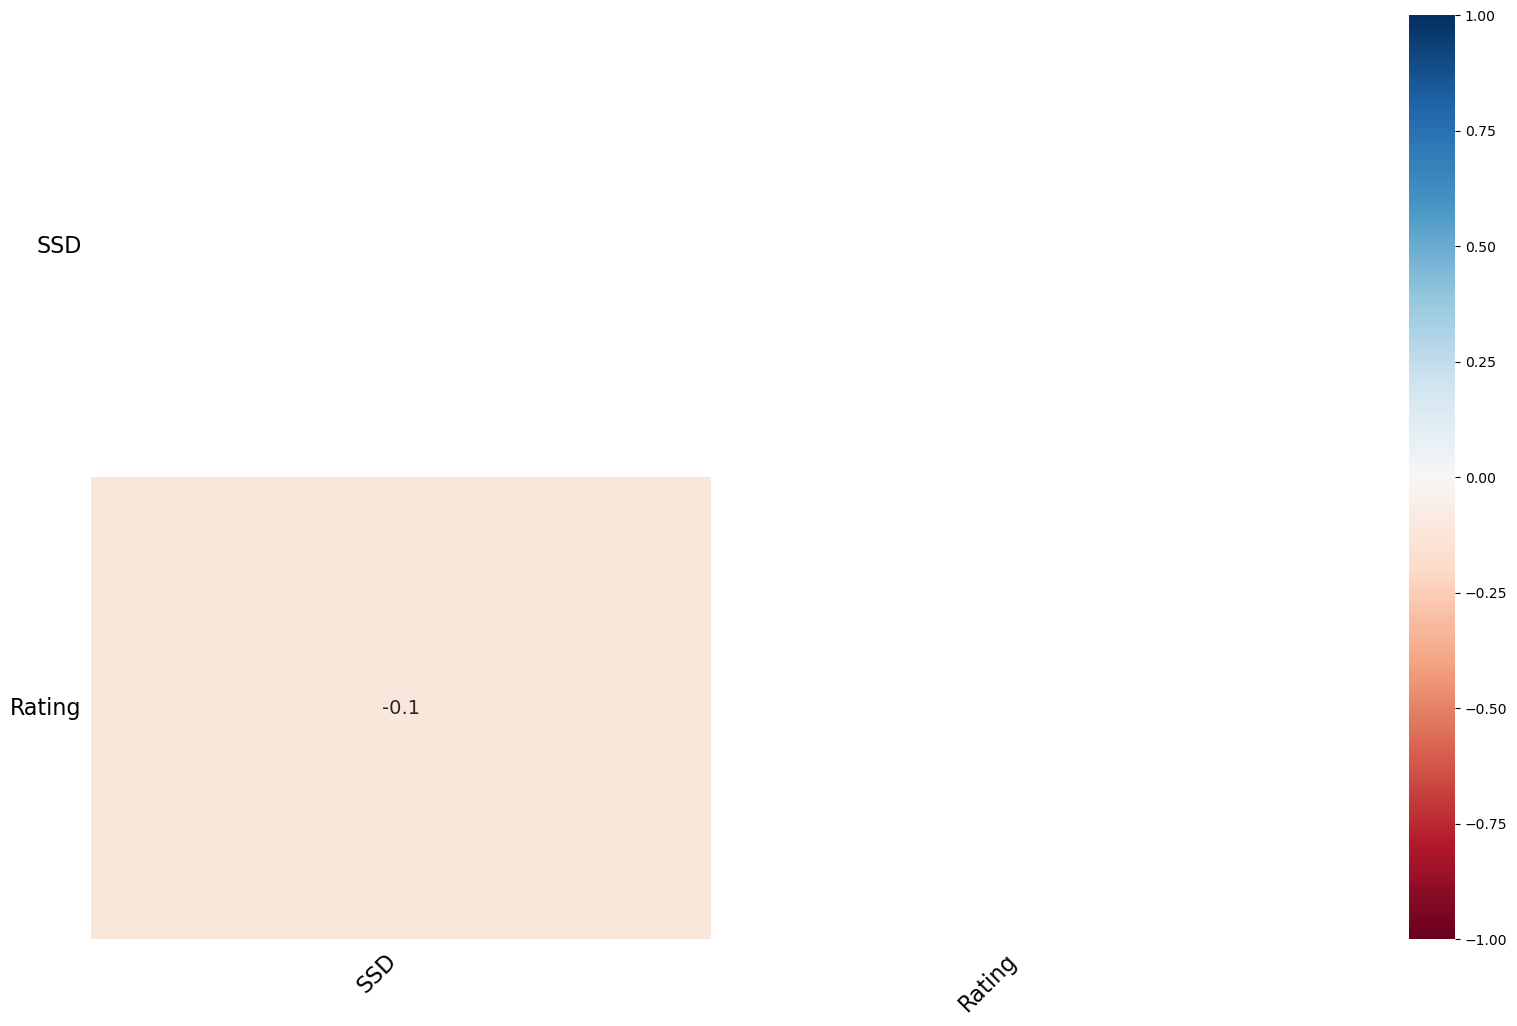

In [12]:
## Visualing missing values
msno.matrix(df)
msno.bar(df)
msno.heatmap(df)

In [13]:
df['SSD'] = df['SSD'].str.extract(r'(\d+)').astype('Int64')         

In [14]:
df.head()

,Brand,Processor,RAM,SSD,Display,Price,Rating,Discount
0,MOTOROLA Motobook 60 Pro Full Metal AI PC 2.8K...,Intel Core Ultra 5 Processor,16 GB DDR5 RAM,512,35.56 cm (14 inch) Display,"₹78,990",4.4,24% off
1,Samsung Galaxy Book4 Metal Intel Core i5 13th ...,Intel Core i5 Processor (13th Gen),8 GB LPDDR4X RAM,512,39.62 cm (15.6 Inch) Display,"₹55,311",4.4,29% off
2,Lenovo Chromebook 11IJL9 Intel Celeron Dual Co...,Intel Celeron Dual Core Processor,4 GB LPDDR4X RAM,<NA>,29.46 cm (11.6 Inch) Display,"₹13,990",4.0,55% off
3,ASUS Vivobook 15 (2025) with Office 2024 + M36...,Intel Core i3 Processor (13th Gen),8 GB DDR5 RAM,512,39.62 cm (15.6 Inch) Display,"₹42,990",4.3,15% off
4,ASUS TUF Gaming A15 (2026) AMD Ryzen 7 170 - (...,AMD Ryzen 7 Processor,16 GB DDR5 RAM,512,39.62 cm (15.6 inch) Display,"₹70,990",4.6,16% off


In [15]:
df['SSD'].fillna(df['SSD'].median())

0     512
1     512
2     512
3     512
4     512
     ... 
67    512
68      1
69      1
70      1
71    512
Name: SSD, Length: 72, dtype: Int64

In [16]:
df['RAM'].fillna('Unknown')

0        16 GB DDR5 RAM
1      8 GB LPDDR4X RAM
2      4 GB LPDDR4X RAM
3         8 GB DDR5 RAM
4        16 GB DDR5 RAM
            ...        
67        8 GB DDR5 RAM
68       16 GB DDR5 RAM
69    32 GB LPDDR5X RAM
70       32 GB DDR5 RAM
71     16 GB LPDDR5 RAM
Name: RAM, Length: 72, dtype: object

In [17]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 43


In [18]:
## To remove duplicate rows
df = df.drop_duplicates()

In [19]:
df

,Brand,Processor,RAM,SSD,Display,Price,Rating,Discount
0,MOTOROLA Motobook 60 Pro Full Metal AI PC 2.8K...,Intel Core Ultra 5 Processor,16 GB DDR5 RAM,512,35.56 cm (14 inch) Display,"₹78,990",4.4,24% off
1,Samsung Galaxy Book4 Metal Intel Core i5 13th ...,Intel Core i5 Processor (13th Gen),8 GB LPDDR4X RAM,512,39.62 cm (15.6 Inch) Display,"₹55,311",4.4,29% off
2,Lenovo Chromebook 11IJL9 Intel Celeron Dual Co...,Intel Celeron Dual Core Processor,4 GB LPDDR4X RAM,<NA>,29.46 cm (11.6 Inch) Display,"₹13,990",4.0,55% off
3,ASUS Vivobook 15 (2025) with Office 2024 + M36...,Intel Core i3 Processor (13th Gen),8 GB DDR5 RAM,512,39.62 cm (15.6 Inch) Display,"₹42,990",4.3,15% off
4,ASUS TUF Gaming A15 (2026) AMD Ryzen 7 170 - (...,AMD Ryzen 7 Processor,16 GB DDR5 RAM,512,39.62 cm (15.6 inch) Display,"₹70,990",4.6,16% off
5,ASUS Vivobook S14 OLED (2026) AI PC with Offic...,Intel Core Ultra 7 Processor (Series 3),16 GB DDR5 RAM,1,35.56 cm (14 inch) Display,"₹1,49,990",4.3,28% off
6,HP 14 AI PC Intel Core Ultra 7 155H - (24 GB/1...,Intel Core Ultra 7 Processor,24 GB DDR5 RAM,1,35.56 cm (14 Inch) Display,"₹87,990",4.1,36% off
7,ASUS ROG Zephyrus G16 OLED (2026) Intel Core U...,Intel Core Ultra 9 Processor,32 GB LPDDR5X RAM,2,40.64 cm (16 inch) Display,"₹4,89,990",NaN,17% off
8,Acer Aspire 15 AMD Office 2024 + M365 Basic AM...,AMD Ryzen 5 Hexa Core Processor,16 GB DDR4 RAM,512,39.62 cm (15.6 Inch) Display,"₹48,990",4.2,43% off
9,ASUS ExpertBook P1 (i3 14th Gen) with 1 Yr ADP...,Intel Core 3 Processor (14th Gen),8 GB DDR5 RAM,512,35.56 cm (14 Inch) Display,"₹49,990",4.3,28% off


In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.shape

(29, 8)

In [22]:
import re

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 0 to 69
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Brand      29 non-null     object 
 1   Processor  29 non-null     object 
 2   RAM        29 non-null     object 
 3   SSD        27 non-null     Int64  
 4   Display    29 non-null     object 
 5   Price      29 non-null     object 
 6   Rating     23 non-null     float64
 7   Discount   29 non-null     object 
dtypes: Int64(1), float64(1), object(6)
memory usage: 2.1+ KB


In [24]:
df['Processor_Brand'] = df['Processor'].str.extract(r'(Intel|AMD)', expand = False)

In [25]:
df['RAM_GB'] = df['RAM'].str.extract(r'(\d+)\s*GB', expand=False).astype(float)

In [26]:
df['Price_Clean'] = df['Price'].astype(str).str.replace(r'[^0-9.]', '', regex=True).astype(float)

In [27]:
df.head()

,Brand,Processor,RAM,SSD,Display,Price,Rating,Discount,Processor_Brand,RAM_GB,Price_Clean
0,MOTOROLA Motobook 60 Pro Full Metal AI PC 2.8K...,Intel Core Ultra 5 Processor,16 GB DDR5 RAM,512,35.56 cm (14 inch) Display,"₹78,990",4.4,24% off,Intel,16.0,78990.0
1,Samsung Galaxy Book4 Metal Intel Core i5 13th ...,Intel Core i5 Processor (13th Gen),8 GB LPDDR4X RAM,512,39.62 cm (15.6 Inch) Display,"₹55,311",4.4,29% off,Intel,8.0,55311.0
2,Lenovo Chromebook 11IJL9 Intel Celeron Dual Co...,Intel Celeron Dual Core Processor,4 GB LPDDR4X RAM,<NA>,29.46 cm (11.6 Inch) Display,"₹13,990",4.0,55% off,Intel,4.0,13990.0
3,ASUS Vivobook 15 (2025) with Office 2024 + M36...,Intel Core i3 Processor (13th Gen),8 GB DDR5 RAM,512,39.62 cm (15.6 Inch) Display,"₹42,990",4.3,15% off,Intel,8.0,42990.0
4,ASUS TUF Gaming A15 (2026) AMD Ryzen 7 170 - (...,AMD Ryzen 7 Processor,16 GB DDR5 RAM,512,39.62 cm (15.6 inch) Display,"₹70,990",4.6,16% off,AMD,16.0,70990.0


In [28]:
df['Brand_Short'] = df['Brand'].str.lower().str.extract(r'^(motoroal|hp|dell|lenovo|asus|acer|msi|apple|samsung)', expand=False)


In [29]:
df.head()

,Brand,Processor,RAM,SSD,Display,Price,Rating,Discount,Processor_Brand,RAM_GB,Price_Clean,Brand_Short
0,MOTOROLA Motobook 60 Pro Full Metal AI PC 2.8K...,Intel Core Ultra 5 Processor,16 GB DDR5 RAM,512,35.56 cm (14 inch) Display,"₹78,990",4.4,24% off,Intel,16.0,78990.0,NaN
1,Samsung Galaxy Book4 Metal Intel Core i5 13th ...,Intel Core i5 Processor (13th Gen),8 GB LPDDR4X RAM,512,39.62 cm (15.6 Inch) Display,"₹55,311",4.4,29% off,Intel,8.0,55311.0,samsung
2,Lenovo Chromebook 11IJL9 Intel Celeron Dual Co...,Intel Celeron Dual Core Processor,4 GB LPDDR4X RAM,<NA>,29.46 cm (11.6 Inch) Display,"₹13,990",4.0,55% off,Intel,4.0,13990.0,lenovo
3,ASUS Vivobook 15 (2025) with Office 2024 + M36...,Intel Core i3 Processor (13th Gen),8 GB DDR5 RAM,512,39.62 cm (15.6 Inch) Display,"₹42,990",4.3,15% off,Intel,8.0,42990.0,asus
4,ASUS TUF Gaming A15 (2026) AMD Ryzen 7 170 - (...,AMD Ryzen 7 Processor,16 GB DDR5 RAM,512,39.62 cm (15.6 inch) Display,"₹70,990",4.6,16% off,AMD,16.0,70990.0,asus


In [30]:
df['Rating'].fillna(df['Rating'].mean())

0     4.400000
1     4.400000
2     4.000000
3     4.300000
4     4.600000
5     4.300000
6     4.100000
7     4.413043
8     4.200000
9     4.300000
11    4.400000
12    4.600000
13    4.100000
14    4.400000
15    4.600000
16    4.300000
17    4.300000
18    4.300000
19    4.300000
20    4.413043
22    5.000000
23    4.400000
44    4.500000
49    4.413043
53    4.413043
58    4.700000
64    4.413043
65    5.000000
69    4.413043
Name: Rating, dtype: float64

In [31]:
df['SSD'].fillna(df['SSD'].median())

0     512
1     512
2     512
3     512
4     512
5       1
6       1
7       2
8     512
9     512
11    512
12      1
13    256
14    512
15    512
16    512
17    512
18    512
19    512
20    512
22      1
23    512
44    512
49    128
53    128
58    512
64    512
65      1
69      1
Name: SSD, dtype: Int64

In [32]:
df['Processor_Brand'] = df['Processor_Brand'].fillna('Unknown')

In [33]:
df['Brand_Short'] = df['Brand_Short'].fillna('Motoroal')

In [34]:
df_csv = pd.DataFrame(df)
df_csv.to_csv("Laptops(Cleaned).csv", index=False)

In [35]:
df_csv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 0 to 69
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Brand            29 non-null     object 
 1   Processor        29 non-null     object 
 2   RAM              29 non-null     object 
 3   SSD              27 non-null     Int64  
 4   Display          29 non-null     object 
 5   Price            29 non-null     object 
 6   Rating           23 non-null     float64
 7   Discount         29 non-null     object 
 8   Processor_Brand  29 non-null     object 
 9   RAM_GB           29 non-null     float64
 10  Price_Clean      29 non-null     float64
 11  Brand_Short      29 non-null     object 
dtypes: Int64(1), float64(3), object(8)
memory usage: 3.0+ KB


In [36]:
df.describe()

,SSD,Rating,RAM_GB,Price_Clean
count,27.0,23.000000,29.000000,29.000000
mean,341.62963,4.413043,15.586207,97707.965517
std,232.343437,0.251006,8.508472,97387.011506
min,1.0,4.000000,4.000000,13990.000000
25%,65.0,4.300000,8.000000,48990.000000
50%,512.0,4.400000,16.000000,57990.000000
75%,512.0,4.550000,16.000000,87990.000000
max,512.0,5.000000,32.000000,489990.000000


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

### UNIVARIATE ANALYSIS

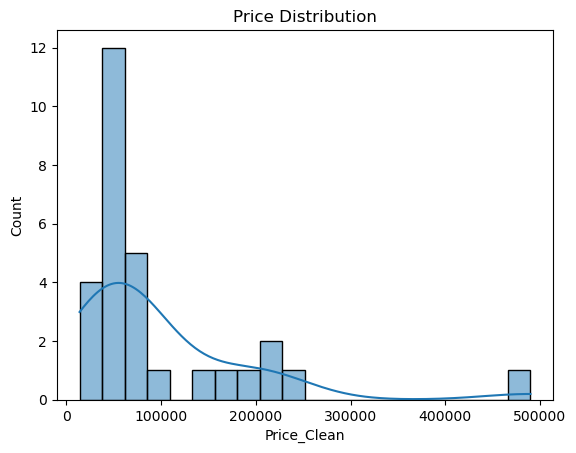

In [38]:
## Price Analysis
sns.histplot(df['Price_Clean'], bins=20, kde=True)
plt.title("Price Distribution")
plt.show()

### According to the price analysis we can say that many laptops are sold within the price range of 1Lakh-2Lakh

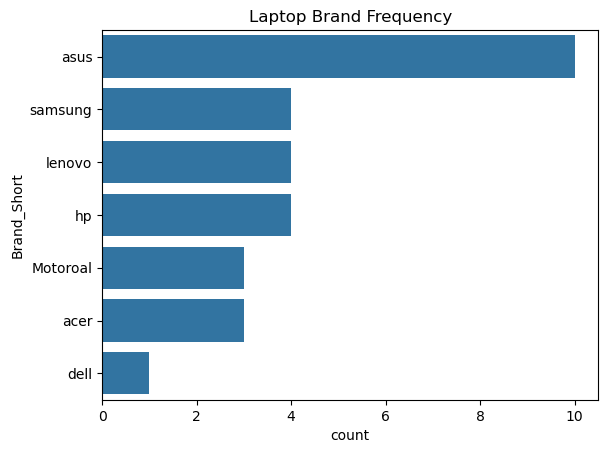

In [39]:
## Most used Brand
sns.countplot(y=df['Brand_Short'], order=df['Brand_Short'].value_counts().index)
plt.title("Laptop Brand Frequency")
plt.show()

### According to Laptop Brand Frequency it's clear that ASUS brand laptops are more in number

In [40]:
## BIVARIATE ANALYSISM

In [41]:
# Laptop count v/s Average price
brand_analysis = df.groupby('Brand_Short').agg(
    Laptop_Count=('Brand_Short', 'count'),
    Average_Price=('Price_Clean', 'mean')
).reset_index()

# Sort by Laptop Count
brand_analysis = brand_analysis.sort_values(by='Laptop_Count', ascending=False)

# Display the summary table
print(brand_analysis)

  Brand_Short  Laptop_Count  Average_Price
2        asus            10  108590.000000
4          hp             4   56740.000000
5      lenovo             4  121865.000000
6     samsung             4  164570.250000
0    Motoroal             3   59323.333333
1        acer             3   47323.333333
3        dell             1   54990.000000


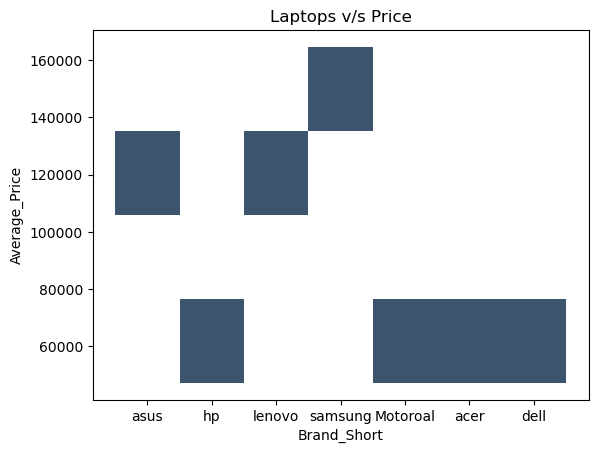

In [42]:
sns.histplot(x = 'Brand_Short', y = 'Average_Price', data = brand_analysis)
plt.title("Laptops v/s Price")
plt.show()

### From the above histplot we can conclude that Samsung Laptops are costly compared to other brands

In [43]:
brand_analysis = df.groupby('Brand_Short').agg(
    Laptop_Count=('Brand_Short', 'count'),
    Average_Rating=('Rating', 'mean')
).reset_index()

# Sort by Laptop Count
brand_analysis = brand_analysis.sort_values(by='Laptop_Count', ascending=False)

# Display the summary table
print(brand_analysis)

  Brand_Short  Laptop_Count  Average_Rating
2        asus            10        4.400000
4          hp             4        4.350000
5      lenovo             4        4.500000
6     samsung             4        4.700000
0    Motoroal             3        4.400000
1        acer             3        4.233333
3        dell             1        4.300000


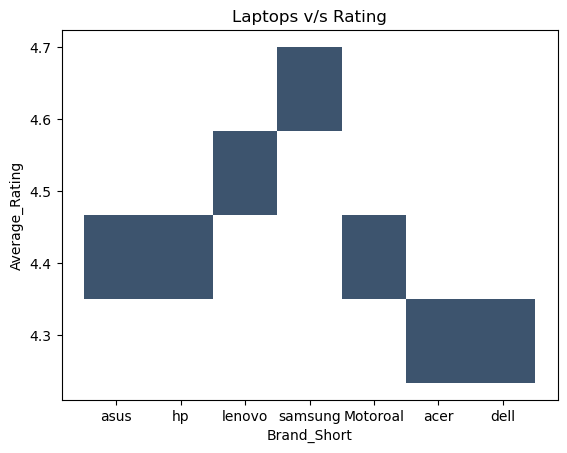

In [44]:
## Brand v/s Rating
sns.histplot(x = 'Brand_Short', y = 'Average_Rating', data = brand_analysis)
plt.title("Laptops v/s Rating")
plt.show()

### From the graph we can conclude that Samsung is highly rated brand in Laptops

In [45]:
df['Discount'] = df['Discount'].astype(str).str.replace(r'[^0-9.]', '', regex=True).astype(float)

In [46]:
df['Discount'] = df['Discount'].astype("int")

In [47]:
brand_analysis = df.groupby('Brand_Short').agg(
    Laptop_Count=('Brand_Short', 'count'),
    Average_Discount=('Discount', 'mean')
).reset_index()

# Sort by Laptop Count
brand_analysis = brand_analysis.sort_values(by='Laptop_Count', ascending=False)

# Display the summary table
print(brand_analysis)

  Brand_Short  Laptop_Count  Average_Discount
2        asus            10         28.700000
4          hp             4         46.500000
5      lenovo             4         30.000000
6     samsung             4         25.750000
0    Motoroal             3         36.333333
1        acer             3         39.666667
3        dell             1         21.000000


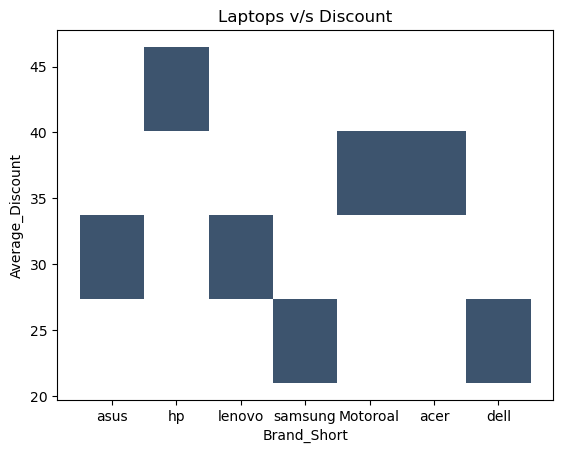

In [48]:
## Brand v/s Discount
sns.histplot(x = 'Brand_Short', y = 'Average_Discount', data = brand_analysis)
plt.title("Laptops v/s Discount")
plt.show()

## It clearly tells that HP offers more mdiscount compared to othersm

## MULTIVARIATE ANALYSIS

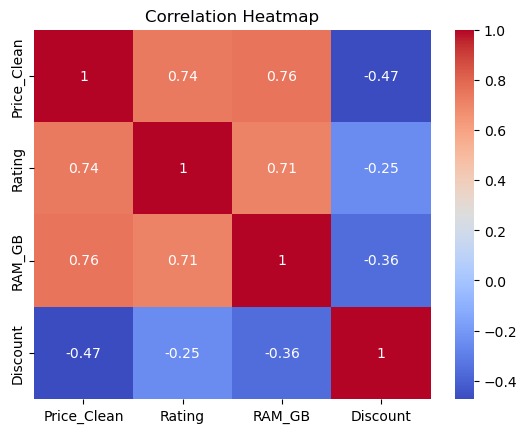

In [52]:
sns.heatmap(df[['Price_Clean','Rating','RAM_GB','Discount']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Interpretation of the Correlation heatmap :
* Price_Clean v/s Rating:
  - Correlation = 0.74
  - Strong and positive correation. Higher price laptops have higher ratings
* Price_Clean v/s RAM_GB :
  - Correlation = 0.76
  - Strong Positive correlation. Laptops with more RAM generally have higher prices
* Price_Clean v/s Discount:
  - Correlation = -0.47
  - Moderate negative correlation. Higher discounts are given to low_priced laptops
* Rating v/s RAM_GB :
  - Correlation = 0.71
  - Strong positive correlation. Higher rating is given to laptops containing better RAM
* Rating v/s Discount :
  - Correlation = -0.25
  - Weakly negative correlation. Higher discounts are given to lower rated laptops
* RAM_GB v/s Discount :
  - Correlation = -0.36
  - Moderate negative correlation. Higher discounts are associated to lower RAM laptops

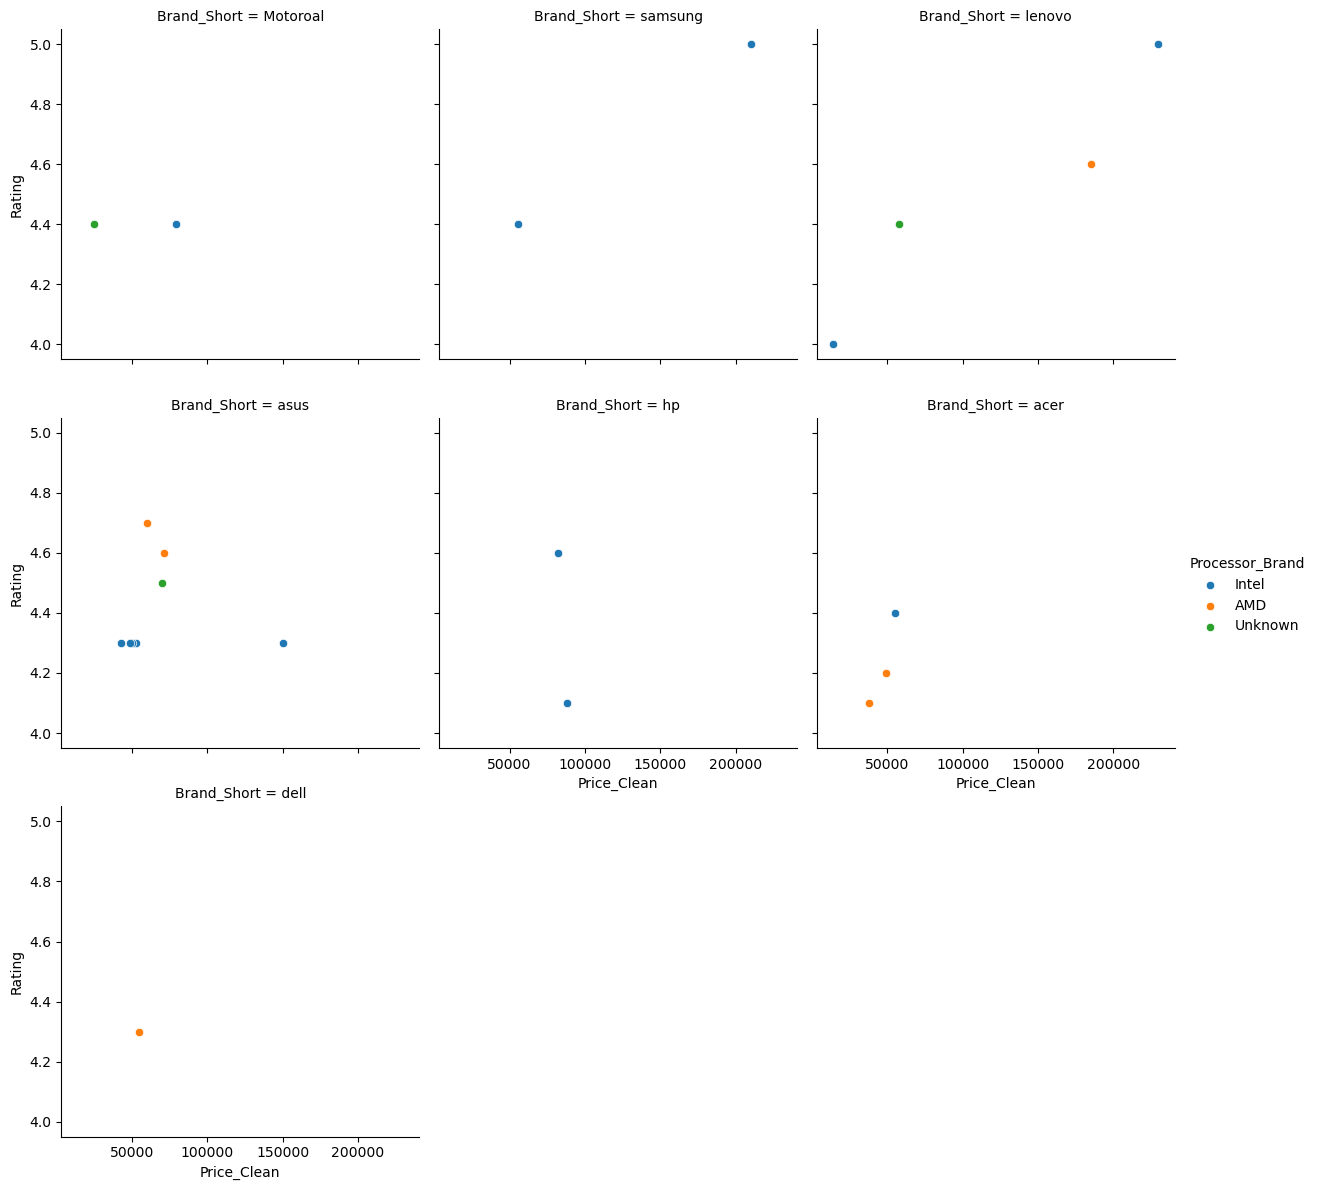

In [53]:
g = sns.FacetGrid(df, col="Brand_Short", hue="Processor_Brand", col_wrap=3, height=4)
g.map(sns.scatterplot, "Price_Clean", "Rating")
g.add_legend()
plt.show()

## Analysis of the above FacetGrid scatter plot
- There is a general positive relationship between Price and Rating—higher-priced laptops often have better ratings.
- Intel processors are the most common across all brands.
- AMD processors appear mainly in ASUS, Acer, and Lenovo.
- Lenovo and ASUS offer the greatest variety of laptops in terms of both price and processor options.
- Budget laptops (₹30,000–₹60,000) generally receive ratings between 4.1 and 4.4, while premium laptops (above ₹1,50,000) often receive ratings of 4.6–5.0.